## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)


In [5]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-01,2010,1,2010-01-01,37.991999,23.654887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,37.991999,23.654887,14643.0,NaN,37.991999,23.654887,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,2010-12-16,37.950174,23.650108,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-16,2010,1,2010-01-01,37.991999,23.654887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,37.991999,23.654887,14292.0,14056.0,37.991999,23.654887,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,2010-01-16,37.950174,23.650108,47.880348,2010-01-09,2010-01-02,2010-12-16,2010-12-16,47.880348,47.880348
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-01,2010,1,2010-01-01,38.009965,23.825567,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,2010-01-01,38.009965,23.825567,14545.0,14253.0,38.009965,23.825567,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,2010-12-16,38.050174,23.850109,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-16,2010,1,2010-01-01,38.009965,23.825567,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,2010-01-16,38.009965,23.825567,14141.0,14041.0,38.009965,23.825567,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,2010-01-16,38.050174,23.850109,43.371546,2010-01-09,2010-01-02,2010-12-16,2010-12-16,43.371546,43.371546
4,αγιου δημητριου,αττικης,23.73031,37.93357,2010-01-01,2010,1,2010-01-01,37.933609,23.731244,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,2010-01-01,37.933609,23.731244,14622.0,14349.0,37.933609,23.731244,14397.75,13992.857143,14356.300000,14154.3,14739.285714,14257.875000,14892.000000,14366.523810,2010-12-16,37.950174,23.750109,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000


In [6]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [7]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [8]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [9]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.0,NaN,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14292.0,14056.0,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,47.880348,47.880348,47.880348
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-01,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.0,14253.0,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-16,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14141.0,14041.0,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,43.371546,43.371546,43.371546
4,αγιου δημητριου,αττικης,23.73031,37.93357,2010-01-01,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.0,14349.0,14397.75,13992.857143,14356.300000,14154.3,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000


In [10]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2010-01-01,αγιας βαρβαρας,αττικης,23.656970,37.992200,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000
1,2010-01-01,αγιας παρασκευης,αττικης,23.826420,38.008060,2010.0,1.0,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000
2,2010-01-01,αγιου δημητριου,αττικης,23.730310,37.933570,2010.0,1.0,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2010.0,1.0,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,0.000000,0.000000,0.000000
4,2010-01-01,αγκιστριου,αττικης,23.340090,37.695030,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19003,2021-12-16,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2021.0,12.0,0.316559,0.137485,-0.282544,-0.137485,0.283007,0.127313,-0.263474,-0.127313,0.031133,0.023760,0.026578,0.023760,14104.000000,13787.000000,14301.555556,14018.538462,14526.125000,14088.473684,14612.416667,14045.800000,14942.200000,14225.588235,1014.150453,49.260338,137.068177
19004,2021-12-16,φυλης,αττικης,23.688620,38.106703,2021.0,12.0,0.346703,0.085737,-0.311130,-0.085737,0.090410,0.162947,-0.049830,-0.162947,0.020864,0.020859,0.015204,0.020859,14057.666667,13689.333333,14155.346348,13835.097222,14407.651593,13977.813045,14452.244444,13881.838492,14747.583333,14047.326923,952.604572,38.901573,132.448505
19005,2021-12-16,χαλανδριου,αττικης,23.809410,38.022260,2021.0,12.0,0.208161,0.102706,-0.203557,-0.102706,0.231337,0.108577,-0.220864,-0.108577,0.046638,0.032328,0.030636,0.032328,14290.000000,13786.000000,14345.875000,13999.923077,14503.222222,14080.400000,14571.833333,14052.533333,14912.333333,14207.307692,1082.514330,66.593548,167.316474
19006,2021-12-16,χαϊδαριου,αττικης,23.630840,38.009420,2021.0,12.0,0.167201,0.172458,-0.027057,-0.172458,0.185951,0.163802,-0.068775,-0.163802,0.055264,0.065290,0.044935,0.065290,14162.000000,13843.000000,14279.214286,13995.111111,14488.812500,14070.055556,14509.800000,14037.058824,14910.875000,14194.214286,1002.432535,36.845405,119.446319


In [11]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [12]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [13]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [14]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [15]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [16]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [17]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [18]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

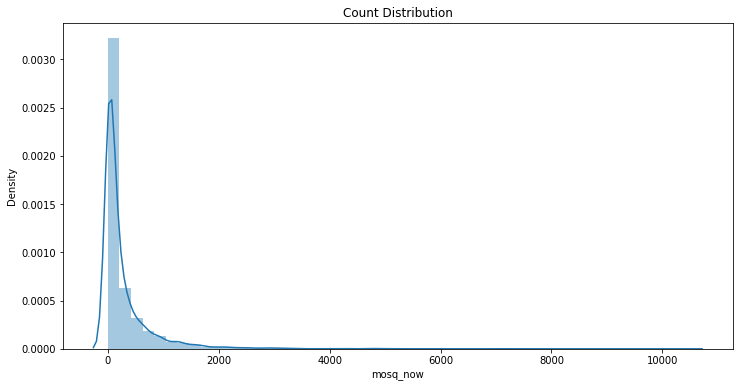

In [19]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [20]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

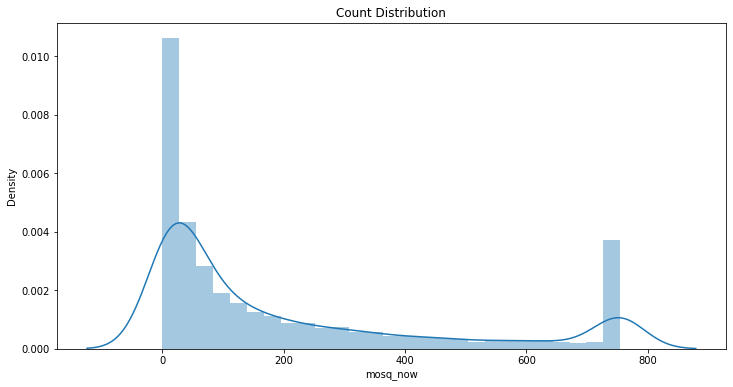

In [21]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

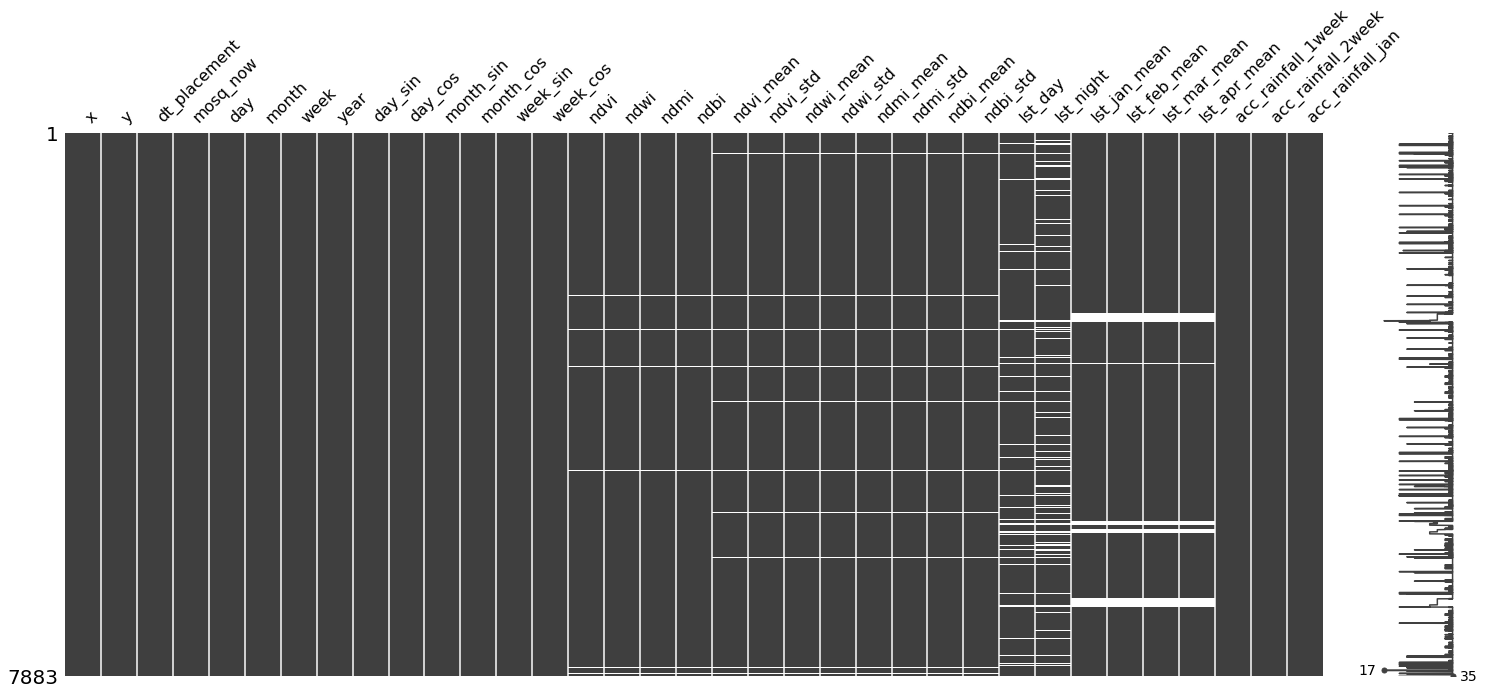

In [22]:
missingno.matrix(mosquito_data_nuts2)

In [23]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [24]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

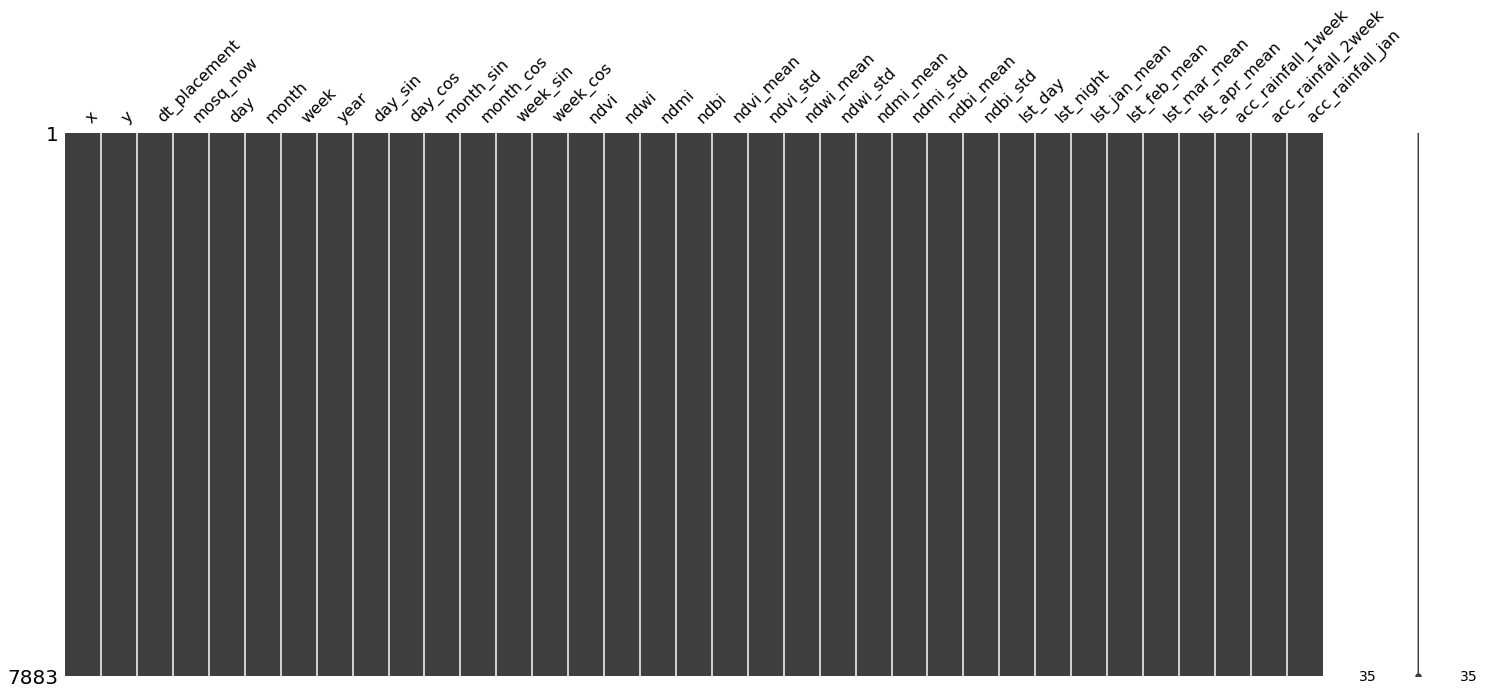

In [25]:
missingno.matrix(mosquito_data_nuts2)

In [26]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [27]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [28]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 20.72449 | Val Loss: 24.01698 | Train Acc: 2.867| Val Acc: 2.281
Epoch 002: | Train Loss: 18.37756 | Val Loss: 24.96700 | Train Acc: 2.223| Val Acc: 2.026
Epoch 003: | Train Loss: 19.00853 | Val Loss: 24.62812 | Train Acc: 2.327| Val Acc: 2.022
Epoch 004: | Train Loss: 18.01705 | Val Loss: 25.21937 | Train Acc: 2.166| Val Acc: 2.027
Epoch 005: | Train Loss: 18.11917 | Val Loss: 23.68821 | Train Acc: 2.146| Val Acc: 2.117
Epoch 006: | Train Loss: 17.32473 | Val Loss: 24.92563 | Train Acc: 2.045| Val Acc: 2.044
Epoch 007: | Train Loss: 17.47012 | Val Loss: 24.44428 | Train Acc: 2.066| Val Acc: 2.124
Epoch 008: | Train Loss: 17.13061 | Val Loss: 23.99394 | Train Acc: 2.024| Val Acc: 2.071
Epoch 009: | Train Loss: 17.07559 | Val Loss: 24.32727 | Train Acc: 2.031| Val Acc: 2.063
Epoch 010: | Train Loss: 16.73809 | Val Loss: 24.41478 | Train Acc: 1.982| Val Acc: 2.085
Epoch 011: | Train Loss: 16.71531 | Val Loss: 24.30062 | Train Acc: 1.996| Val Acc: 2.137
Epoch 012:

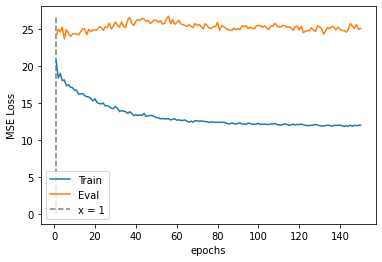

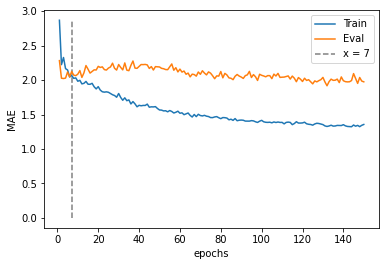

In [29]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [30]:
metrics(train, test, threshold=30)

MAE on train set:  133.49365228301247
min prediction: 1
max prediction: 1361

MAE on test set:  158.74348918729456
Error ⩽ 30: 18.97 %
min prediction: 1
max prediction: 1579


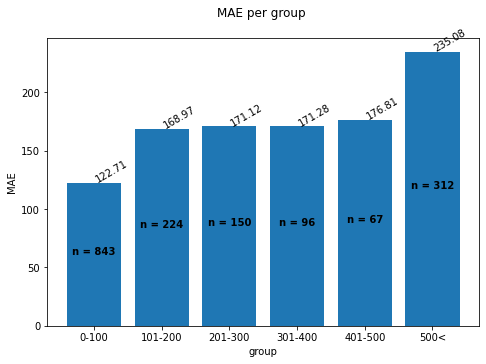

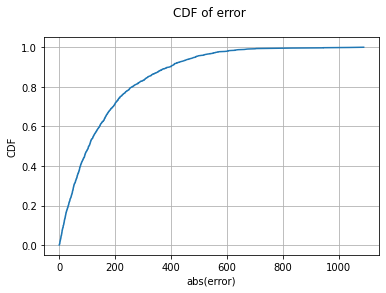

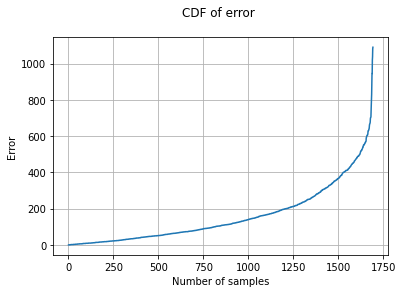

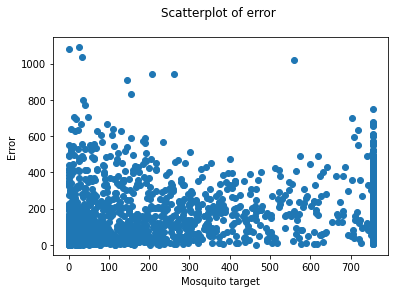

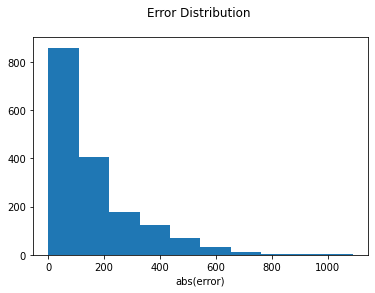

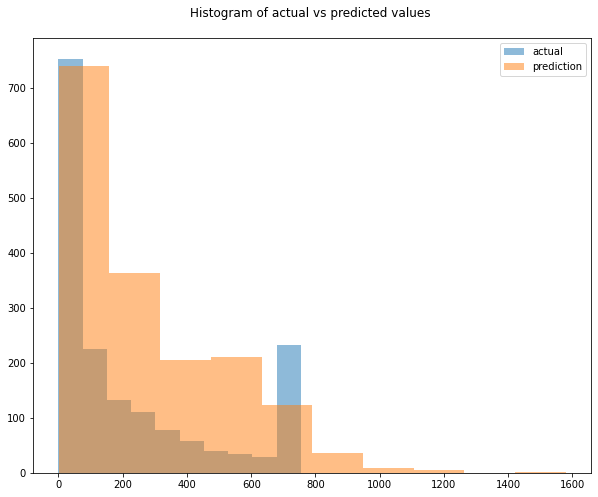

In [31]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.55733 | Val Loss: 2.52204 | Train Acc: 1.514| Val Acc: 1.633
Epoch 002: | Train Loss: 13.50799 | Val Loss: 2.50949 | Train Acc: 1.507| Val Acc: 1.633
Epoch 003: | Train Loss: 13.57012 | Val Loss: 1.86671 | Train Acc: 1.522| Val Acc: 1.633
Epoch 004: | Train Loss: 13.32111 | Val Loss: 2.47258 | Train Acc: 1.505| Val Acc: 1.633
Epoch 005: | Train Loss: 13.19479 | Val Loss: 2.12569 | Train Acc: 1.484| Val Acc: 1.633
Epoch 006: | Train Loss: 13.16211 | Val Loss: 1.98483 | Train Acc: 1.481| Val Acc: 1.633
Epoch 007: | Train Loss: 13.11421 | Val Loss: 1.29962 | Train Acc: 1.478| Val Acc: 1.633
Epoch 008: | Train Loss: 13.03606 | Val Loss: 2.20574 | Train Acc: 1.473| Val Acc: 1.633
Epoch 009: | Train Loss: 13.03557 | Val Loss: 2.16686 | Train Acc: 1.471| Val Acc: 1.633
Epoch 010: | Train Loss: 12.98177 | Val Loss: 3.32574 | Train Acc: 1.468| Val Acc: 1.633
Epoch 011: | Train Loss: 12.96145 | Val Loss: 3.03463 | Train Acc: 1.474| Val Acc: 1.633
Epoch 012: | Train Lo

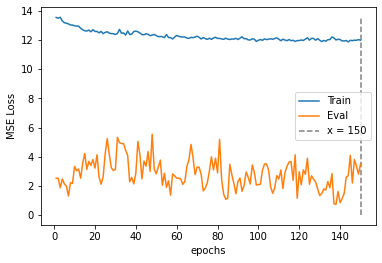

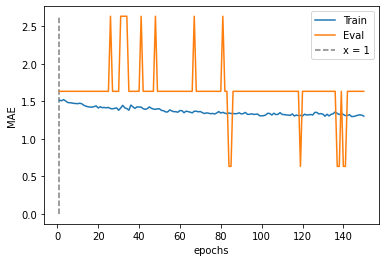

In [32]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [33]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [34]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [35]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [36]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [37]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [38]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

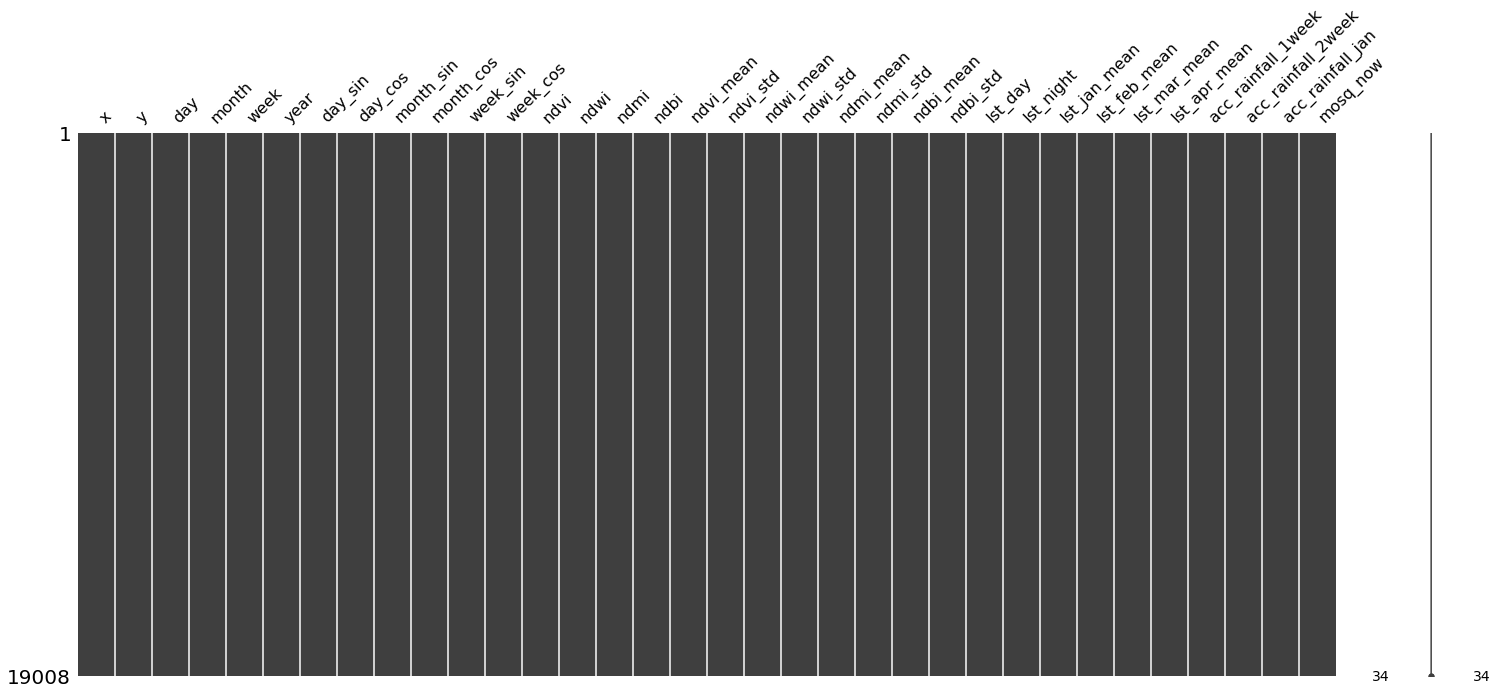

In [39]:
missingno.matrix(dataset_mamoth)

In [40]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [41]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [42]:
predictions = give_predictions(model, dataset_mamoth)

In [43]:
mosqutio_predictions['mosq_pred'] = predictions

In [44]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.656970,37.992200,2010-01-01,29
1,23.826420,38.008060,2010-01-01,27
2,23.730310,37.933570,2010-01-01,38
3,23.713410,38.047210,2010-01-01,35
4,23.340090,37.695030,2010-01-01,38
...,...,...,...,...
19003,23.776280,38.014770,2021-12-16,1
19004,23.688620,38.106703,2021-12-16,1
19005,23.809410,38.022260,2021-12-16,1
19006,23.630840,38.009420,2021-12-16,1


In [45]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2021.csv', index = False)